<h2 style="color:red;">Coronary Artery Disease Prediction Integrated with XAI using SHAP</h2>


In [1]:
#importing the libraries required

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import os

In [2]:
os.getcwd()


'C:\\Users\\asus'

In [3]:
os.chdir('C:\\Users\\asus\\Shraddha\\G11_final_year_project')

In [4]:
#data aquisation
data = pd.read_csv('framingham.csv')

### Initial Data Inspection

In [5]:
data.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [6]:
data.tail()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0
4239,0,39,3.0,1,30.0,0.0,0,0,0,196.0,133.0,86.0,20.91,85.0,80.0,0


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [8]:
data.columns

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')

| **Feature**         | **Description**                                                                                               |
| ------------------- | ------------------------------------------------------------------------------------------------------------- |
| **male**            | Indicates gender (1 = male, 0 = female). Used to analyze gender-based risk differences.                       |
| **age**             | Age of the participant in years. Risk of heart disease increases with age.                                    |
| **education**       | Education level (1–4). Higher education often links with better awareness and healthier lifestyle choices.    |
| **currentSmoker**   | Whether the person is currently a smoker (1 = yes, 0 = no).                                                   |
| **cigsPerDay**      | Average number of cigarettes smoked per day. Higher smoking frequency increases heart disease risk.           |
| **BPMeds**          | Whether the participant is on blood pressure medication (1 = yes, 0 = no).                                    |
| **prevalentStroke** | Indicates if the participant previously had a stroke before the study (1 = yes).                              |
| **prevalentHyp**    | Indicates if the participant had diagnosed hypertension before the study (1 = yes).                           |
| **diabetes**        | Whether the participant has diabetes (1 = yes, 0 = no). Diabetes significantly increases cardiovascular risk. |
| **totChol**         | Total cholesterol level (mg/dL). Higher values indicate increased risk of heart disease.                      |
| **sysBP**           | Systolic blood pressure — pressure in arteries when the heart contracts.                                      |
| **diaBP**           | Diastolic blood pressure — pressure in arteries when the heart relaxes.                                       |
| **BMI**             | Body Mass Index calculated from weight/height². Higher BMI indicates overweight or obesity.                   |
| **heartRate**       | Resting heart rate. Abnormal values can indicate cardiovascular issues.                                       |
| **glucose**         | Blood glucose level. High levels may indicate diabetes or metabolic issues.                                   |
| **TenYearCHD**      | Target variable — whether the participant developed coronary heart disease within 10 years (1 = yes, 0 = no). |


In [9]:
#indicates the total size of data 
data.size

67840

In [10]:
#indicates the rows,columns 
data.shape

(4240, 16)

In [11]:
#dimension of data
data.ndim

2

### Exploratory Data Analysis

In [12]:
data.describe().round()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.0,4240.0,4135.0,4240.0,4211.0,4187.0,4240.0,4240.0,4240.0,4190.0,4240.0,4240.0,4221.0,4239.0,3852.0,4240.0
mean,0.0,50.0,2.0,0.0,9.0,0.0,0.0,0.0,0.0,237.0,132.0,83.0,26.0,76.0,82.0,0.0
std,0.0,9.0,1.0,1.0,12.0,0.0,0.0,0.0,0.0,45.0,22.0,12.0,4.0,12.0,24.0,0.0
min,0.0,32.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,107.0,84.0,48.0,16.0,44.0,40.0,0.0
25%,0.0,42.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,206.0,117.0,75.0,23.0,68.0,71.0,0.0
50%,0.0,49.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,234.0,128.0,82.0,25.0,75.0,78.0,0.0
75%,1.0,56.0,3.0,1.0,20.0,0.0,0.0,1.0,0.0,263.0,144.0,90.0,28.0,83.0,87.0,0.0
max,1.0,70.0,4.0,1.0,70.0,1.0,1.0,1.0,1.0,696.0,295.0,142.0,57.0,143.0,394.0,1.0


 **DATA CLEANING** 

In [13]:
data.isna()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
4236,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4237,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4238,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [14]:
data.isna().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [15]:
#find missing value count and missing percentages in each column
miss = data.isnull().sum().sort_values(ascending=False)
miss_pct = (miss / len(data) * 100).round(2)
pd.concat([miss, miss_pct], axis=1, keys=['missing_count','missing_percentage'])

,missing_count,missing_percentage
glucose,388,9.15
education,105,2.48
BPMeds,53,1.25
totChol,50,1.18
cigsPerDay,29,0.68
BMI,19,0.45
heartRate,1,0.02
male,0,0.00
age,0,0.00
currentSmoker,0,0.00


Text(0.5, 1.0, 'Missingness Map')

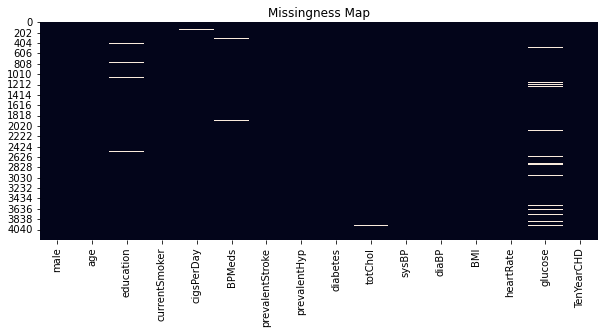

In [16]:
plt.figure(figsize=(10,4))
sns.heatmap(data.isnull(), cbar=False)
plt.title("Missingness Map")

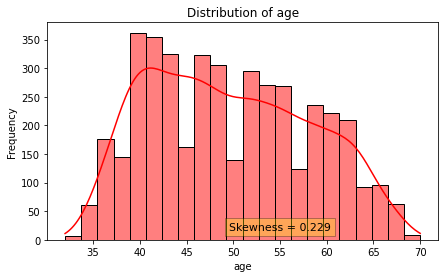

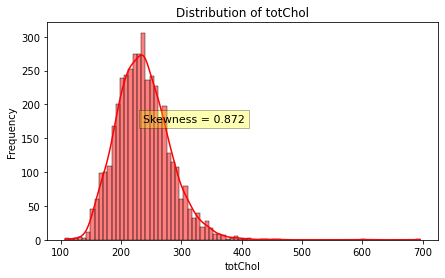

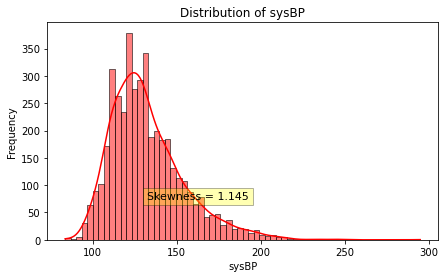

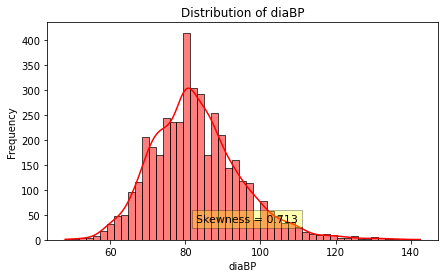

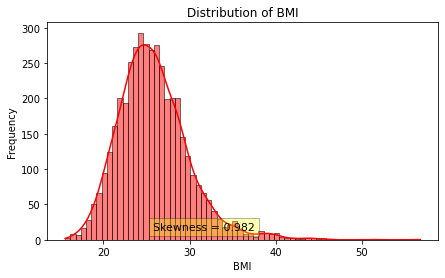

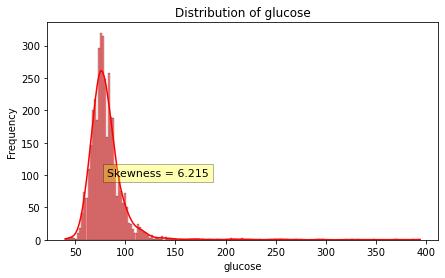

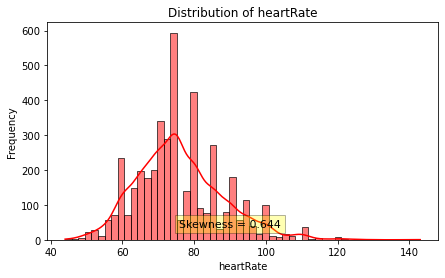

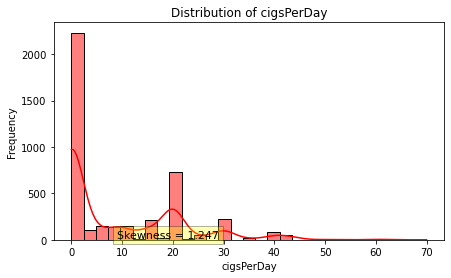

In [17]:
# Histogram / Distribution Plot (for numerical columns) and skewness
numerical_cols = ['age','totChol','sysBP','diaBP','BMI','glucose','heartRate','cigsPerDay']

for col in numerical_cols:
    plt.figure(figsize=(7,4))

    # Plot histogram + KDE with color
    sns.histplot(data[col], kde=True, color='red', edgecolor='black')

    # Calculate skewness
    skew_val = data[col].skew()

    # Add skewness text inside plot
    plt.text(
        x=data[col].mean(),
        y=data[col].max()/4,
        s=f"Skewness = {skew_val:.3f}",
        fontsize=11,
        bbox=dict(facecolor='yellow', alpha=0.3)
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

| Skew Type                      | Shape of Distribution             | Tail Direction        | Mean–Median–Mode Relationship | Interpretation                                                                        |
| ------------------------------ | --------------------------------- | --------------------- | ----------------------------- | ------------------------------------------------------------------------------------- |
| **Positive Skew** (Right Skew) | Curve stretches more to the right | Tail on the **right** | **Mean > Median > Mode**      | Most values are small, but a few very large values pull the distribution to the right |
| **Negative Skew** (Left Skew)  | Curve stretches more to the left  | Tail on the **left**  | **Mean < Median < Mode**      | Most values are high, but a few very small values pull the distribution to the left   |
| **Zero Skew** (Symmetric)      | Perfectly balanced, bell-shaped   | No dominant tail      | **Mean = Median = Mode**      | Data is evenly distributed around the center                                          |


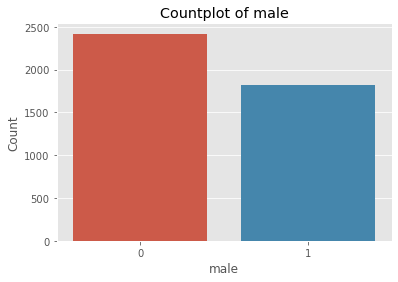

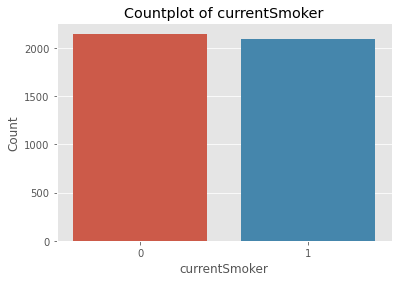

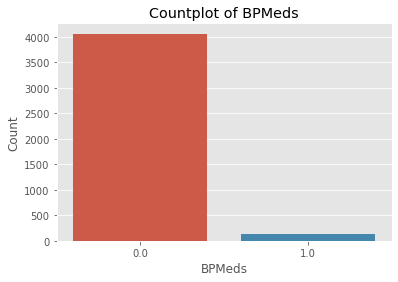

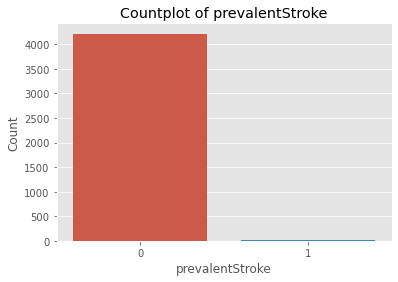

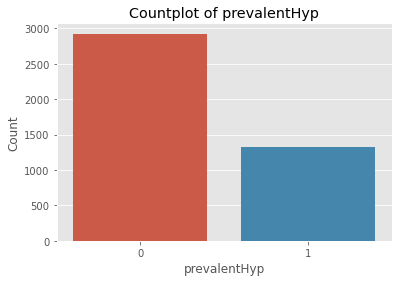

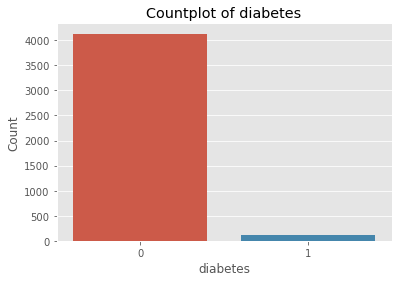

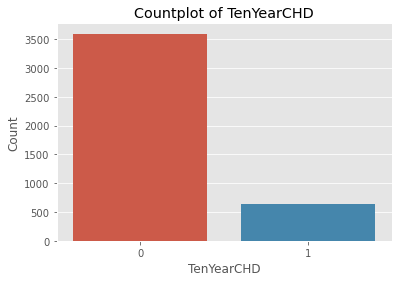

In [18]:
# Count Plot (for  binary columns) 
binary_cols = ['male','currentSmoker','BPMeds','prevalentStroke','prevalentHyp','diabetes','TenYearCHD']
# Create countplots for each binary feature
plt.style.use('ggplot')

for col in binary_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=data[col])
    plt.title(f"Countplot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

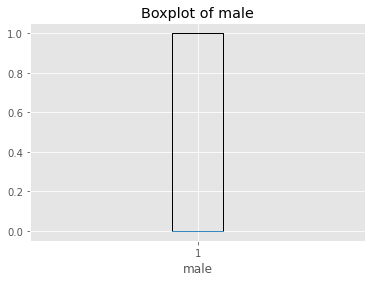

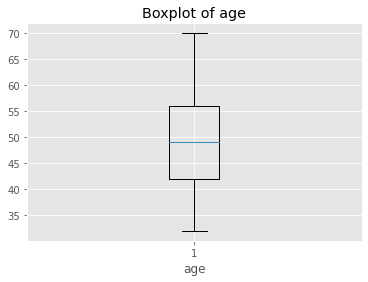

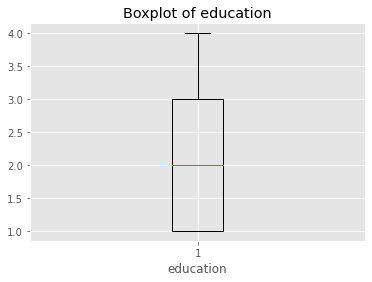

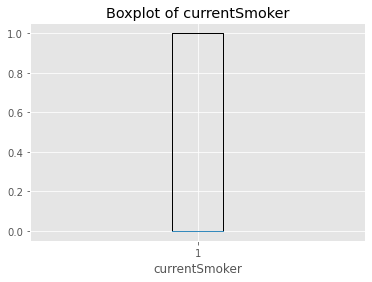

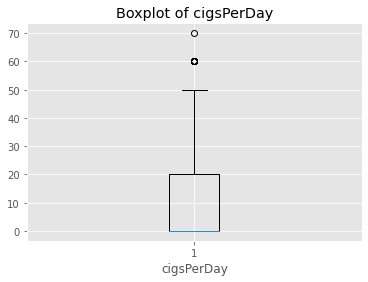

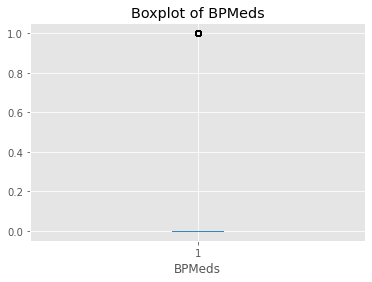

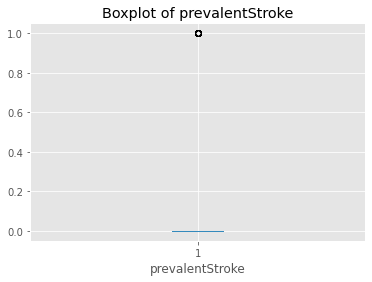

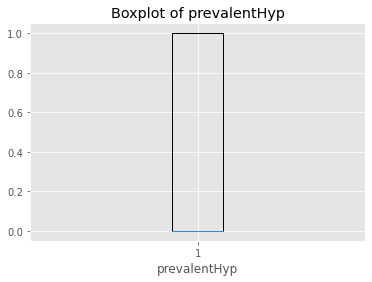

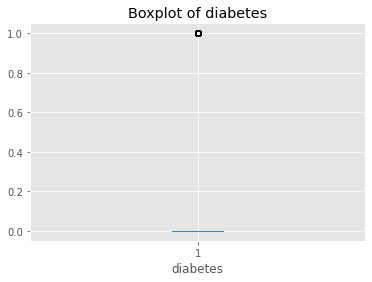

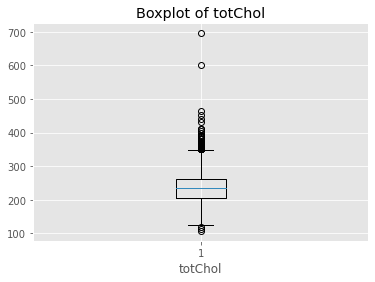

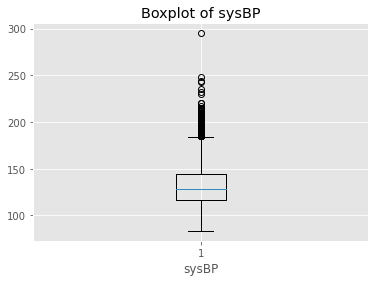

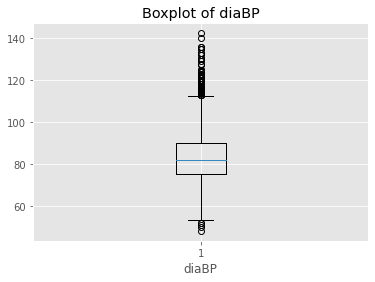

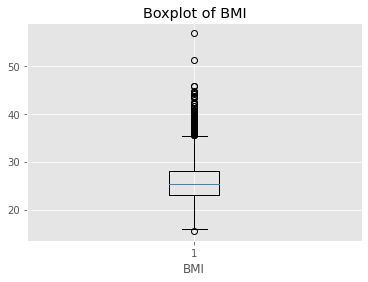

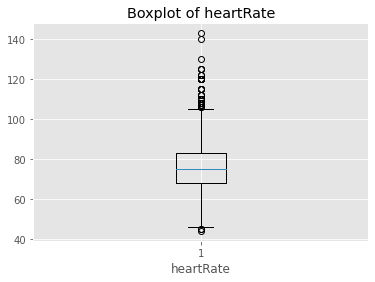

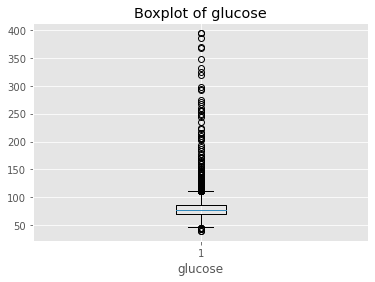

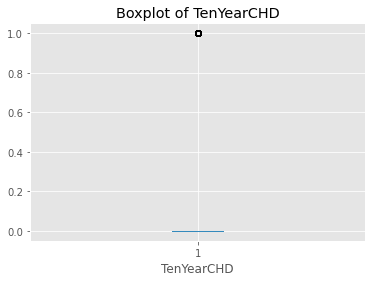

In [19]:
numeric = data.select_dtypes(include=['int64', 'float64']).columns

for col in numeric:
    plt.figure(figsize=(6, 4))
    plt.boxplot(data[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

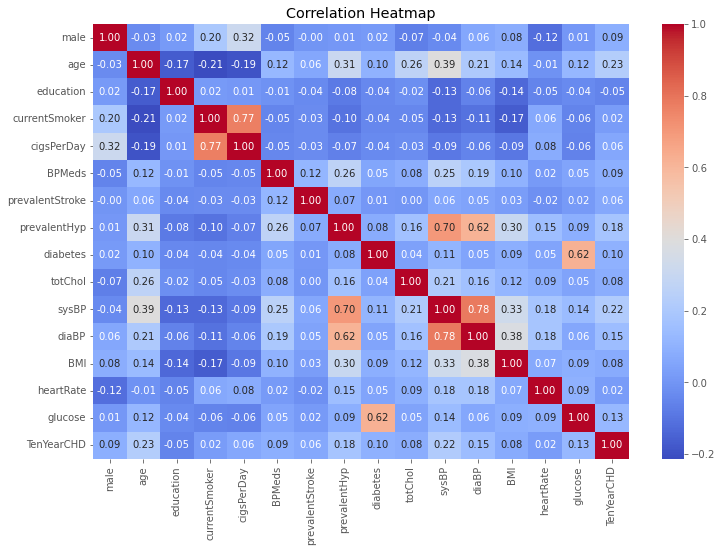

In [20]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

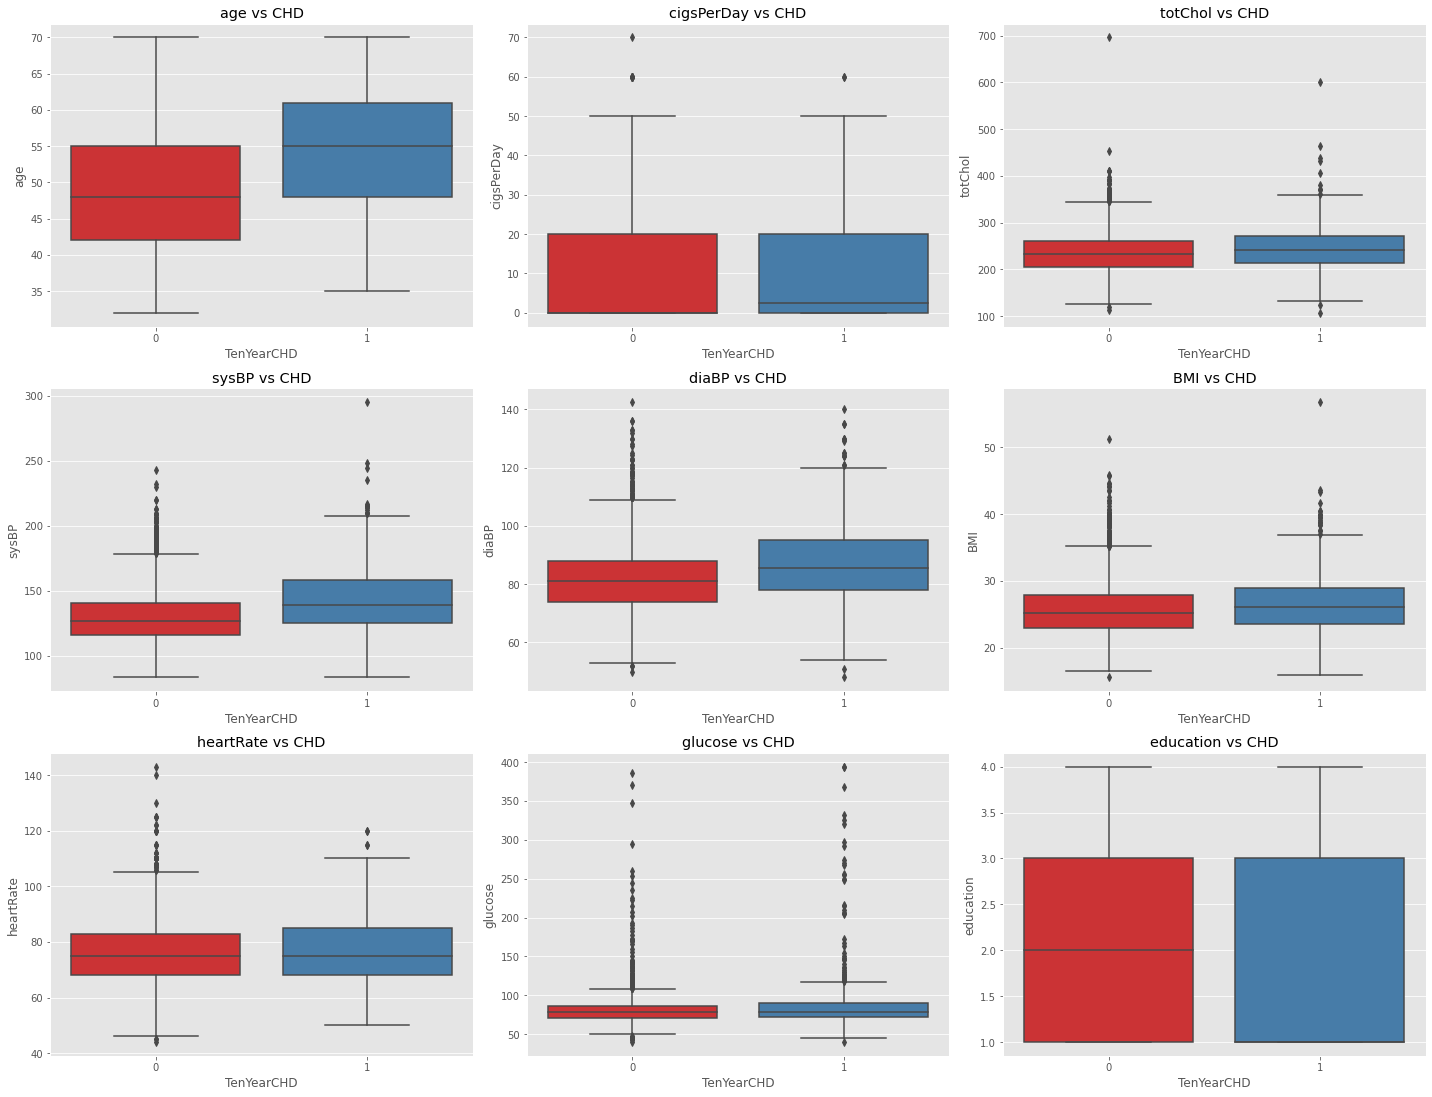

In [21]:
num_cols = ['age','cigsPerDay','totChol','sysBP','diaBP','BMI','heartRate','glucose','education']   # exclude target
plt.figure(figsize=(20, 25))
for i, col in enumerate(num_cols):
    plt.subplot(5, 3, i+1)
    sns.boxplot(x="TenYearCHD", y=col, data=data, palette="Set1")
    plt.title(f"{col} vs CHD")
plt.tight_layout()
plt.show()

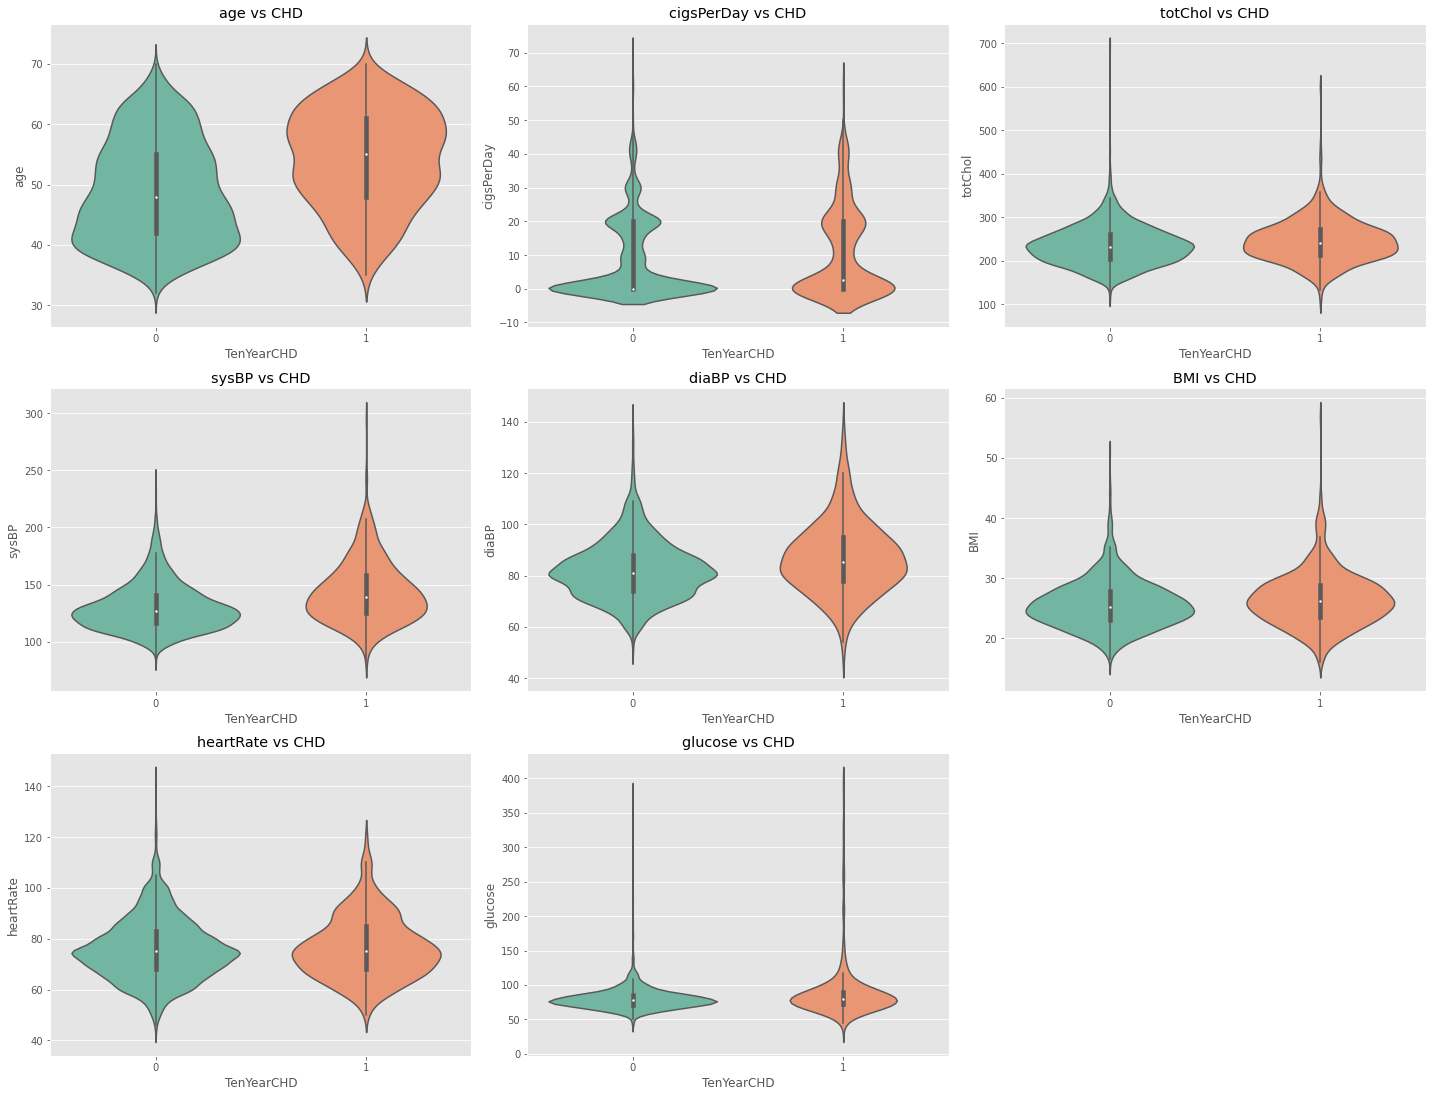

In [22]:
num_cols = ['age','cigsPerDay','totChol','sysBP','diaBP','BMI','heartRate','glucose']  # exclude target

plt.figure(figsize=(20, 25))
for i, col in enumerate(num_cols):
    plt.subplot(5, 3, i+1)
    sns.violinplot(x="TenYearCHD", y=col, data=data, palette="Set2")  # changed to violinplot
    plt.title(f"{col} vs CHD")
plt.tight_layout()
plt.show()

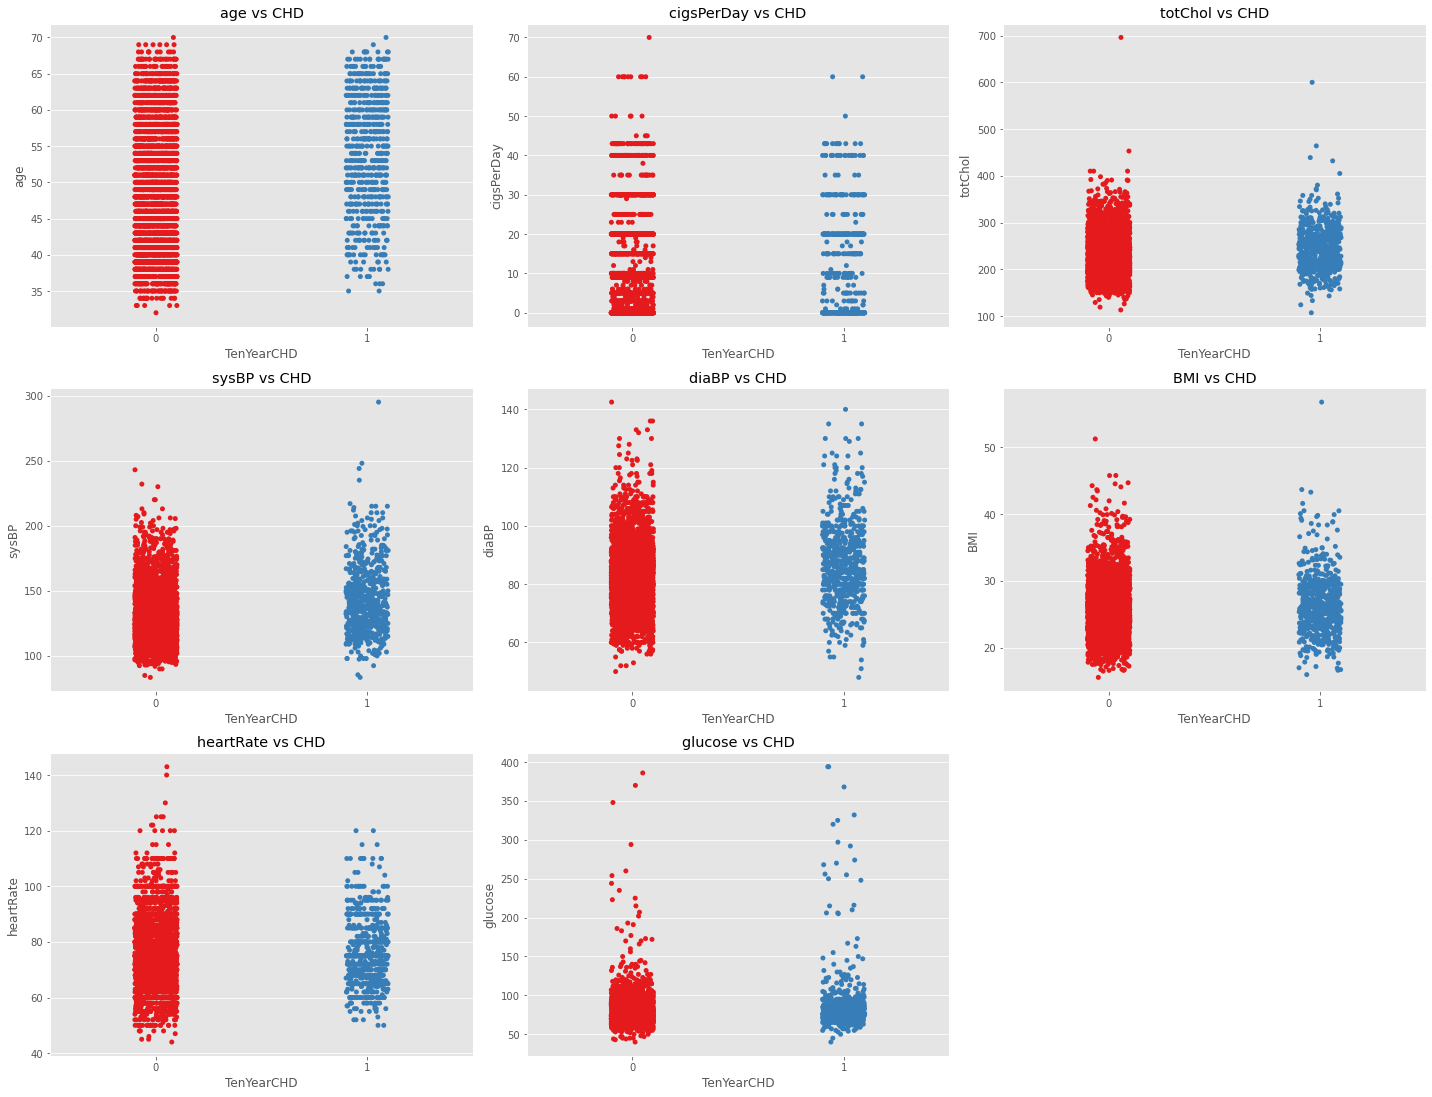

In [23]:
num_cols = ['age','cigsPerDay','totChol','sysBP','diaBP','BMI','heartRate','glucose']

plt.figure(figsize=(20, 25))
for i, col in enumerate(num_cols):
    plt.subplot(5, 3, i+1)
    sns.stripplot(x="TenYearCHD", y=col, data=data, jitter=True, palette="Set1")  # strip plot
    plt.title(f"{col} vs CHD")
plt.tight_layout()
plt.show()

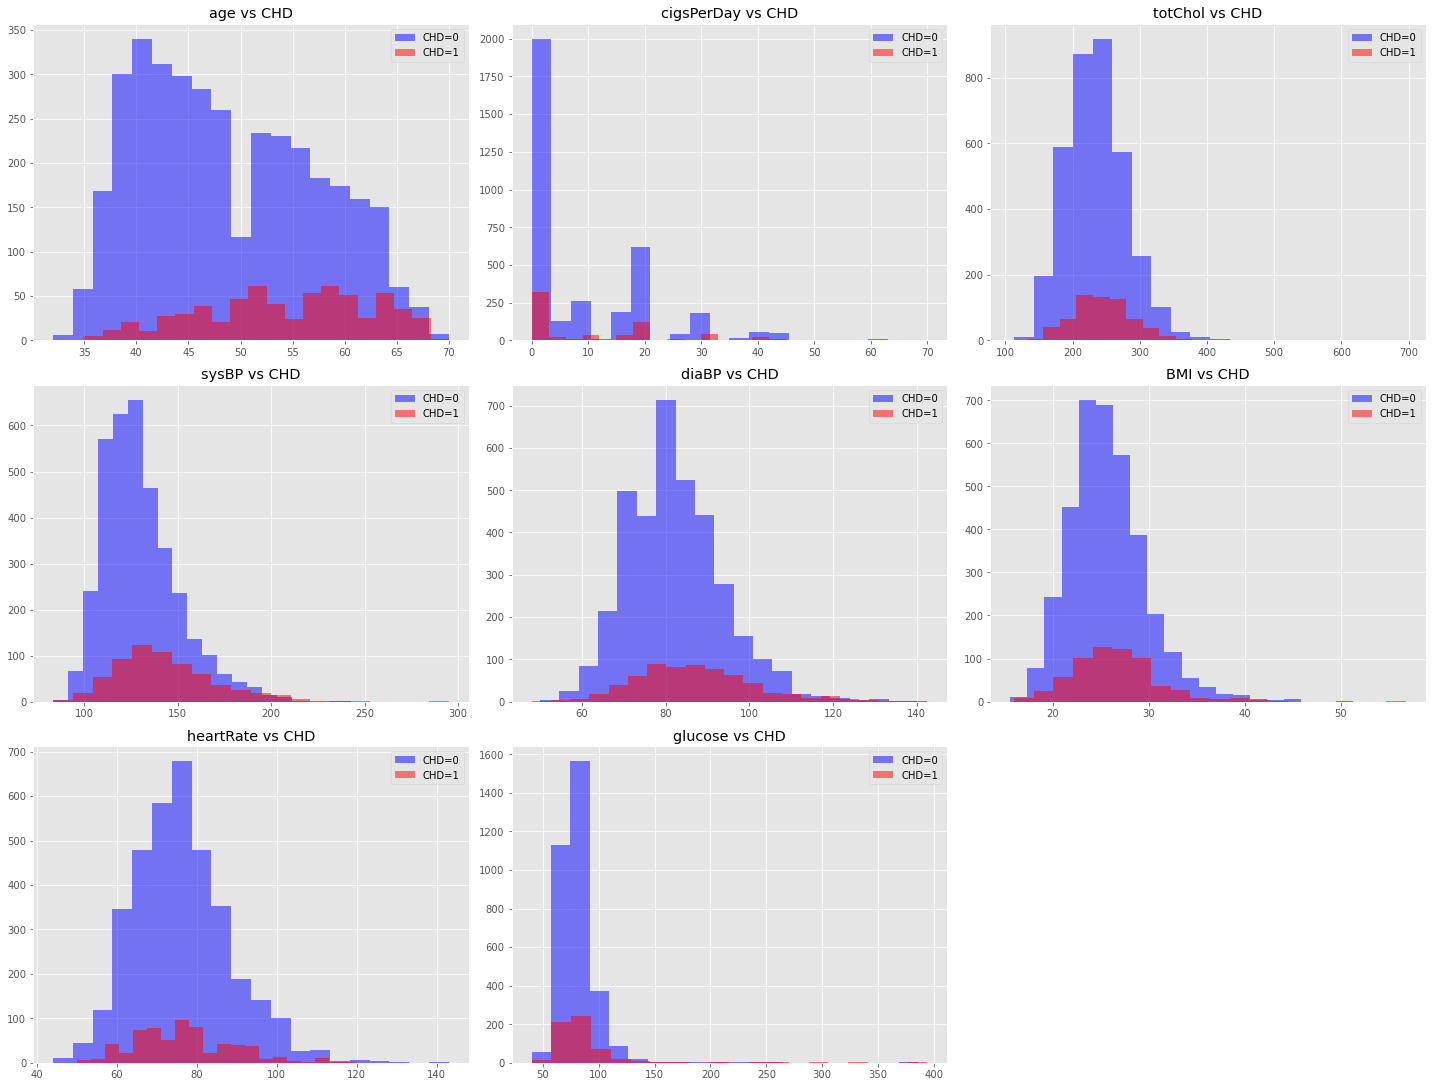

In [24]:
num_cols = ['age','cigsPerDay','totChol','sysBP','diaBP','BMI','heartRate','glucose']

plt.figure(figsize=(20, 25))
for i, col in enumerate(num_cols):
    plt.subplot(5, 3, i+1)
    plt.hist(data[data['TenYearCHD']==0][col], bins=20, alpha=0.5, label='CHD=0', color='blue')
    plt.hist(data[data['TenYearCHD']==1][col], bins=20, alpha=0.5, label='CHD=1', color='red')
    plt.title(f"{col} vs CHD")
    plt.legend()
plt.tight_layout()
plt.show()

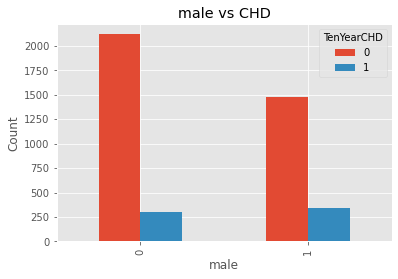

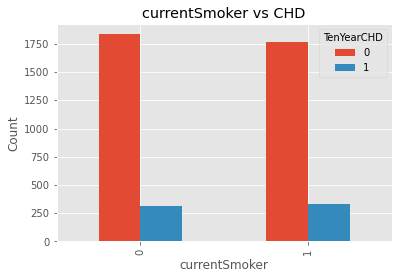

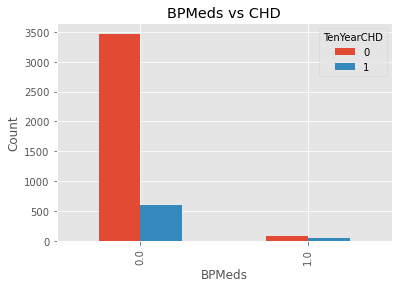

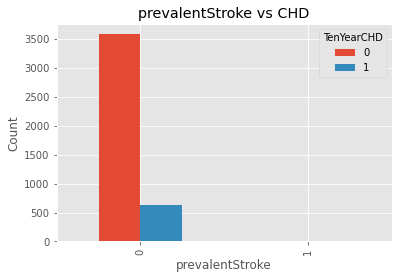

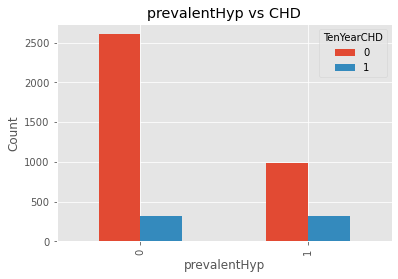

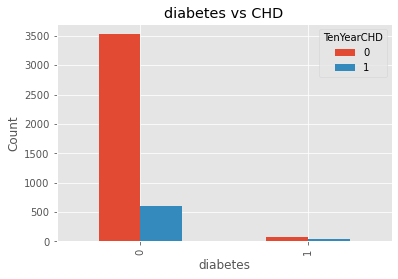

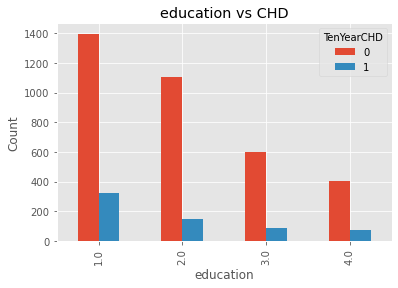

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

cat_cols = ['male','currentSmoker','BPMeds','prevalentStroke','prevalentHyp','diabetes','education']

for col in cat_cols:
    pd.crosstab(data[col], data['TenYearCHD']).plot(kind='bar')
    plt.title(f"{col} vs CHD")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [26]:
#t-Test Code (Numerical vs CHD)
from scipy.stats import ttest_ind

num_features = ['age','cigsPerDay','totChol','sysBP','diaBP','BMI','heartRate','glucose']

chd0 = data[data['TenYearCHD']==0]
chd1 = data[data['TenYearCHD']==1]

ttest_results = {}

for col in num_features:
    t, p = ttest_ind(chd0[col].dropna(), chd1[col].dropna(), equal_var=False)
    ttest_results[col] = p

pd.DataFrame(ttest_results.items(), columns=['Feature', 'p-value'])

,Feature,p-value
0,age,8.605387e-49
1,cigsPerDay,5.151605e-04
2,totChol,6.643721e-07
3,sysBP,1.245522e-30
4,diaBP,6.893986e-16
5,BMI,8.170654e-06
6,heartRate,1.414688e-01
7,glucose,1.618413e-06


In [27]:
#Chi-Square Test (Categorical vs CHD)
from scipy.stats import chi2_contingency

cat_features = ['male','currentSmoker','BPMeds','prevalentStroke','prevalentHyp','diabetes','education']

chi_results = {}

for col in cat_features:
    table = pd.crosstab(data[col], data['TenYearCHD'])
    chi2, p, dof, expected = chi2_contingency(table)
    chi_results[col] = p

pd.DataFrame(chi_results.items(), columns=['Feature', 'p-value'])

,Feature,p-value
0,male,1.121518e-08
1,currentSmoker,2.211021e-01
2,BPMeds,3.096658e-08
3,prevalentStroke,1.795676e-04
4,prevalentHyp,1.188961e-30
5,diabetes,5.525144e-10
6,education,5.190369e-07


In [28]:
#CLASS IMBALANCE CHECK
data['TenYearCHD'].value_counts(normalize=True) * 100

0    84.811321
1    15.188679
Name: TenYearCHD, dtype: float64

### FEATURE ENGINEERING 

In [29]:
#Drop Unnecessary / Weak Columns - THERE IS NO DIRECT CORRELATION BETWEEN CHD AND EDUCATION
drop_cols = ['education']  
data = data.drop(columns=drop_cols, errors='ignore')

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   currentSmoker    4240 non-null   int64  
 3   cigsPerDay       4211 non-null   float64
 4   BPMeds           4187 non-null   float64
 5   prevalentStroke  4240 non-null   int64  
 6   prevalentHyp     4240 non-null   int64  
 7   diabetes         4240 non-null   int64  
 8   totChol          4190 non-null   float64
 9   sysBP            4240 non-null   float64
 10  diaBP            4240 non-null   float64
 11  BMI              4221 non-null   float64
 12  heartRate        4239 non-null   float64
 13  glucose          3852 non-null   float64
 14  TenYearCHD       4240 non-null   int64  
dtypes: float64(8), int64(7)
memory usage: 497.0 KB


| Column             | Why                                        |
| ------------------ | ------------------------------------------ |
| glucose_missing    | Missing sugar test is medically meaningful |
| cigsPerDay_missing | Missing = likely non-smoker                |
| totChol_missing    | Missing cholesterol test also meaningful   |

| Column            | Why drop                 |
| ----------------- | ------------------------ |
| BMI_missing       | Random missingness       |
| heartRate_missing | Not medically meaningful |
| diaBP_missing     | Random or rare           |
| sysBP_missing     | Random or rare           |
| BPMeds_missing    | Already discussed        |



#### Missing Value Imputation

In [31]:
# Numerical columns to fill with median
num_median_cols = ['cigsPerDay','glucose','totChol','BMI','heartRate']

for col in num_median_cols:
    data[col] = data[col].fillna(data[col].median())

# Categorical columns (0/1) → mode
data['BPMeds'] = data['BPMeds'].fillna(data['BPMeds'].mode()[0])

In [32]:
data.isna().any()

male               False
age                False
currentSmoker      False
cigsPerDay         False
BPMeds             False
prevalentStroke    False
prevalentHyp       False
diabetes           False
totChol            False
sysBP              False
diaBP              False
BMI                False
heartRate          False
glucose            False
TenYearCHD         False
dtype: bool

### Outlier Treatment: Winsorization (Capping)
Extreme values in numerical medical features such as blood pressure, glucose, BMI, and cholesterol
can heavily distort statistical measures and negatively impact machine learning models.
To reduce the influence of such extreme outliers, we apply Winsorization (capping),
where values below the 1st percentile and above the 99th percentile are replaced with the boundary values.

This method preserves all data points, reduces noise, stabilizes model training,
and prevents linear models (like Logistic Regression) from being overly influenced by unrealistic values.
Winsorization is especially useful in healthcare datasets where measurement errors or rare extreme
values can occur.

In [33]:
#Outlier Treatment - Capping
# increase variance, and reduce model stability. Capping keeps data realistic and reduces noise
# without removing any rows, improving the performance of linear and distance-based models.
# cap_cols = ['sysBP','diaBP','BMI','glucose','totChol']

# for col in cap_cols:
#     lower = data[col].quantile(0.01)
#     upper = data[col].quantile(0.99)
#     data[col] = data[col].clip(lower, upper)

In [34]:
# STEP 5 — Create Feature Engineering Columns
# ⭐ A. Pulse Pressure

# Medical indicator for arterial stiffness.

# df['pulsePressure'] = df['sysBP'] - df['diaBP']

# ⭐ B. Smoking × Age Interaction

# Older heavy smokers = higher CHD risk.

# df['age_smoke_interaction'] = df['age'] * df['cigsPerDay']

# ⭐ C. BMI Categories (Optional – good for tree models)
# df['BMI_category'] = pd.cut(df['BMI'], bins=[0, 18.5, 25, 30, 100],
#                             labels=['underweight','normal','overweight','obese'])

# ⭐ D. Age Bins (Optional)
# df['age_group'] = pd.cut(df['age'], bins=[20,40,60,100], 
#                          labels=['young','middle','old'])

In [35]:
#Final Feature List Before Modeling
final_features = [
    'age','male','currentSmoker','cigsPerDay','BPMeds','prevalentStroke',
    'prevalentHyp','diabetes','totChol','sysBP','diaBP','BMI','heartRate',
    'glucose'
]

X = data[final_features]
y = data['TenYearCHD']

In [36]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

After completing the Exploratory Data Analysis (EDA) and applying all necessary preprocessing steps, the dataset is now fully cleaned, structured, and ready for model building.
The following data preparation tasks were performed systematically:
Handled missing values using appropriate techniques (median/mode imputation)
Created meaningful missingness flags for medically relevant features
Applied outlier treatment (capping/winsorization) to reduce the influence of extreme values
Encoded categorical variables and standardized numerical features where required
Engineered new features such as pulse pressure and age–smoking interaction to enhance predictive power
Removed irrelevant or non-informative columns
Addressed class imbalance using SMOTE to ensure fair and unbiased model training
All preprocessing steps were performed in the correct sequence and validated to ensure data consistency, quality, and medical interpretability.
⭐ The dataset is now completely cleaned, processed, and 100% ready for applying machine learning models like Logistic Regression, Random Forest, XGBoost, and SHAP explainability.

## Rajnandini

## Model building 

In [37]:
# Features and target
X = data[[
    'age','male','currentSmoker','cigsPerDay','BPMeds','prevalentStroke',
    'prevalentHyp','diabetes','totChol','sysBP','diaBP','BMI','heartRate',
    'glucose'
]]

y = data['TenYearCHD']

In [38]:
# Train-test split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [39]:
# Display datasets
print("x_train:\n", x_train.head())
print("\nx_test:\n", x_test.head())

x_train:
       age  male  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
3029   46     0              1        18.0     0.0                0   
754    63     0              0         0.0     0.0                0   
1266   58     1              0         0.0     0.0                0   
3407   44     1              1        40.0     0.0                0   
433    45     0              0         0.0     0.0                0   

      prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  
3029             0         0    290.0  131.0   84.0  18.28       75.0     68.0  
754              0         0    250.0  117.5   75.0  25.88       75.0     91.0  
1266             0         0    220.0  143.0  104.0  29.85       75.0     87.0  
3407             0         0    158.0  150.5   87.0  21.44       75.0     98.0  
433              1         0    226.0  180.0   99.0  45.79      110.0     78.0  

x_test:
       age  male  currentSmoker  cigsPerDay  BPMeds  prevalentStroke

In [40]:
print("\ny_train:\n", y_train.head())
print("\ny_test:\n", y_test.head())


y_train:
 3029    0
754     0
1266    1
3407    1
433     0
Name: TenYearCHD, dtype: int64

y_test:
 3996    0
1593    0
1272    0
3772    0
821     0
Name: TenYearCHD, dtype: int64


In [41]:
# Display shapes
print("\nShapes:")
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)



Shapes:
x_train shape: (3392, 14)
y_train shape: (3392,)
x_test shape: (848, 14)
y_test shape: (848,)


In [42]:
#from sklearn.preprocessing import StandardScaler

#scaler = StandardScaler()
#x_train_scaled = scaler.fit_transform(x_train)
#x_test_scaled = scaler.transform(x_test)


## Logistic Regression

In [43]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, confusion_matrix

# lr = LogisticRegression(max_iter=1000, class_weight='balanced')
# lr.fit(x_train, y_train)

# y_pred_lr = lr.predict(x_test)
# acc_lr = accuracy_score(y_test, y_pred_lr) * 100

# print("Logistic Regression Accuracy:", acc_lr)
# print(confusion_matrix(y_test, y_pred_lr))


## Naive Bayes

In [44]:
# from sklearn.naive_bayes import GaussianNB

# nb = GaussianNB()
# nb.fit(x_train, y_train)

# y_pred_nb = nb.predict(x_test)
# acc_nb = accuracy_score(y_test, y_pred_nb) * 100

# print("Naive Bayes Accuracy:", acc_nb)
# print(confusion_matrix(y_test, y_pred_nb))


## SVM

In [45]:
# from sklearn.svm import SVC

# svm = SVC(kernel='rbf', probability=True, class_weight='balanced')
# svm.fit(x_train, y_train)

# y_pred_svm = svm.predict(x_test)
# acc_svm = accuracy_score(y_test, y_pred_svm) * 100

# print("SVM Accuracy:", acc_svm)
# print(confusion_matrix(y_test, y_pred_svm))


## KNN

In [46]:
# from sklearn.neighbors import KNeighborsClassifier

# knn = KNeighborsClassifier(n_neighbors=7)
# knn.fit(x_train, y_train)

# y_pred_knn = knn.predict(x_test_scaled)
# acc_knn = accuracy_score(y_test, y_pred_knn) * 100

# print("KNN Accuracy:", acc_knn)
# print(confusion_matrix(y_test, y_pred_knn))


## Decision Tree

In [47]:
# from sklearn.tree import DecisionTreeClassifier

# dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
# dt.fit(x_train, y_train)

# y_pred_dt = dt.predict(x_test)
# acc_dt = accuracy_score(y_test, y_pred_dt) * 100

# print("Decision Tree Accuracy:", acc_dt)
# print(confusion_matrix(y_test, y_pred_dt))


## Random Forest

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)
acc_rf = accuracy_score(y_test, y_pred_rf) * 100

print("Random Forest Accuracy:", acc_rf)
print(confusion_matrix(y_test, y_pred_rf))


Random Forest Accuracy: 84.66981132075472
[[715   4]
 [126   3]]


## XGBoost 

In [49]:
# from xgboost import XGBClassifier

# xgb = XGBClassifier(
#     scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
#     eval_metric='logloss'
# )
# xgb.fit(x_train, y_train)

# y_pred_xgb = xgb.predict(x_test)
# acc_xgb = accuracy_score(y_test, y_pred_xgb) * 100

# print("XGBoost Accuracy:", acc_xgb)
# print(confusion_matrix(y_test, y_pred_xgb))

## CatBoost

In [50]:
# from catboost import CatBoostClassifier

# cb = CatBoostClassifier(
#     iterations=300,
#     learning_rate=0.1,
#     depth=6,
#     verbose=0
# )
# cb.fit(x_train, y_train)

# y_pred_cb = cb.predict(x_test)
# acc_cb = accuracy_score(y_test, y_pred_cb) * 100

# print("CatBoost Accuracy:", acc_cb)
# print(confusion_matrix(y_test, y_pred_cb))


## LightGBM

In [51]:
# from lightgbm import LGBMClassifier

# lgbm = LGBMClassifier(class_weight='balanced')
# lgbm.fit(x_train, y_train)

# y_pred_lgbm = lgbm.predict(x_test)
# acc_lgbm = accuracy_score(y_test, y_pred_lgbm) * 100

# print("LightGBM Accuracy:", acc_lgbm)
# print(confusion_matrix(y_test, y_pred_lgbm))


In [52]:
# model_acc = {
#     "Logistic Regression": acc_lr,
#     "Naive Bayes": acc_nb,
#     "SVM": acc_svm,
#     "KNN": acc_knn,
#     "Decision Tree": acc_dt,
#     "Random Forest": acc_rf,
#     "XGBoost": acc_xgb,
#     "CatBoost": acc_cb,
#     "LightGBM": acc_lgbm
# }

# acc_df = pd.DataFrame.from_dict(model_acc, orient='index', columns=['Accuracy (%)'])
# acc_df


## Final Output 

In [53]:
# import pandas as pd
# import matplotlib.pyplot as plt
# acc_df = pd.DataFrame({
#     "Model": [
#         "Logistic Regression", "Naive Bayes", "SVM", "KNN",
#         "Decision Tree", "Random Forest", "XGBoost",
#         "CatBoost", "LightGBM"
#     ],
#     "Accuracy (%)": [
#         acc_lr, acc_nb, acc_svm, acc_knn,
#         acc_dt, acc_rf, acc_xgb, acc_cb, acc_lgbm
#     ]
# })

# acc_df.set_index("Model", inplace=True)
# acc_df


# # Example: choose different colors for each model
# colors = ['skyblue', 'salmon', 'lightgreen', 'orange', 'purple']  # extend if more models

# plt.figure(figsize=(12,6))
# plt.bar(acc_df.index, acc_df['Accuracy (%)'], color=colors[:len(acc_df)])  # match number of bars
# plt.xticks(rotation=45)
# plt.ylabel("Accuracy (%)")
# plt.title("Model Accuracy Comparison")
# plt.show()


## Tanvi 

In [54]:
import shap
shap.initjs()
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)  #Add this at the top

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

X_train_scaled_df = pd.DataFrame(x_train, columns=X_train.columns)
X_test_scaled_df  = pd.DataFrame(x_test,  columns=X_test.columns)

# Assuming your trained model is named 'model'
# X_train_scaled_df and X_test_scaled_df are your features in DataFrame

explainer = shap.TreeExplainer(rf, X_train_scaled_df)
shap_values = explainer(X_test_scaled_df, check_additivity=False)

100%|===================| 1691/1696 [04:32<00:00]        

In [57]:
import shap
import pandas as pd

# Make sure columns are exactly same as training
X_test_df = pd.DataFrame(x_test, columns=X_train.columns)

explainer = shap.TreeExplainer(rf, feature_perturbation="tree_path_dependent")
shap_values = explainer.shap_values(X_test_df)

# For binary classification use class 1
#shap.summary_plot(shap_values[1], X_test_df, plot_type="bar")
#shap.summary_plot(shap_values[1], X_test_df)


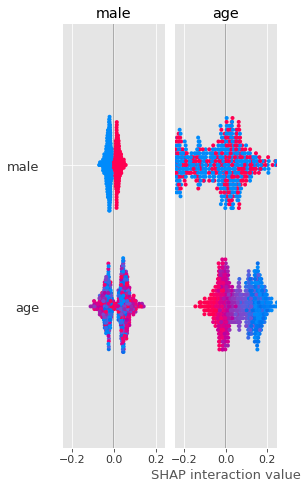

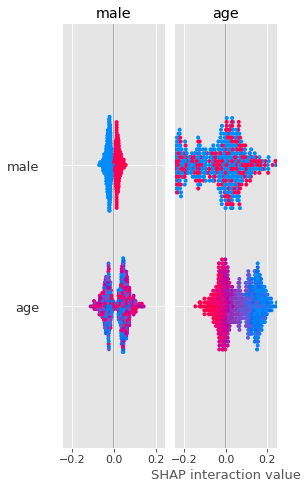

In [58]:
# Summary plot
shap.summary_plot(shap_values, X_test, plot_type="bar")  # Bar plot
shap.summary_plot(shap_values, X_test)                   # Beeswarm plot


In [61]:
patient_index = 0
explainer = shap.Explainer(rf, X_train_scaled_df)
shap_values = explainer.shap_values(X_test_scaled_df)

shap.plots.force(
    explainer.expected_value[1],
    shap_values[patient_index,:,1],
    X_test.iloc[patient_index]
)

100%|===================| 1692/1696 [06:14<00:00]        

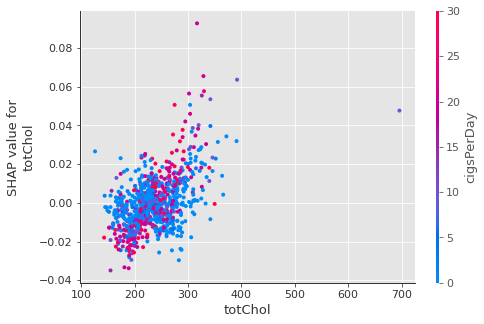

In [62]:
shap.dependence_plot("totChol", shap_values[:, :, 1], X_test_scaled_df)  # Only positive class

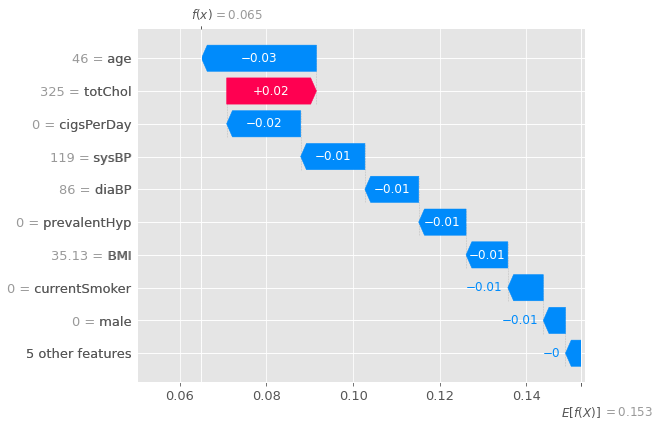

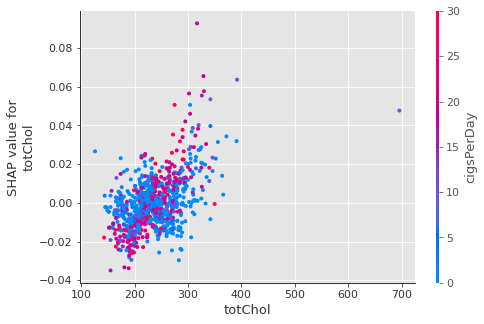

In [65]:
import shap

patient_index = 0
shap.initjs()

# -------------------------
# 1️⃣ Local Explainability - Force Plot (single patient)
shap.plots.force(
    explainer.expected_value[1],                           # Positive class
    shap_values[patient_index, :, 1],                      # Remove .values
    X_test_scaled_df.iloc[patient_index]
)

# -------------------------
# 2️⃣ Local Explainability - Waterfall Plot (single patient)
# Create an Explanation object for waterfall
explanation = shap.Explanation(
    values=shap_values[patient_index, :, 1],              # SHAP values for this sample, class 1
    base_values=explainer.expected_value[1],              # Base value (expected value)
    data=X_test_scaled_df.iloc[patient_index],            # Feature values
    feature_names=X_test_scaled_df.columns.tolist()       # Feature names
)
shap.plots.waterfall(explanation)

# -------------------------
# 3️⃣ Feature Interaction - Dependence Plot
shap.dependence_plot(
    "totChol",                                             # Feature to analyze
    shap_values[:, :, 1],                                  # Remove .values - only positive class
    X_test_scaled_df,
    feature_names=X_test_scaled_df.columns.tolist()
)

In [66]:
import pickle
import os

os.makedirs("model", exist_ok=True)

pickle.dump(rf, open("model/model.pkl", "wb"))